# Telecom Customer Churn Analysis

## Data Loading

Import the required libraries and load the telecom customer churn dataset.

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

#Load dataset
df = pd.read_csv(r"C:\Users\Abc\Desktop\Telecom Customer churn\Data\Telco-Customer-Churn.csv")
print(df.head())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

## Data Quality Assessment

The objective of this step is to evaluate the quality of the dataset before analysis. This includes checking the dataset dimensions, data types, missing values, duplicate records, and ensuring that numerical columns are stored in the correct format.

### 1. Dataset Shape

Check the number of rows and columns in the dataset.

In [5]:
print(df.shape)

(7043, 21)


### 2. Dataset Information

Examine column names, data types, and non-null values.

In [6]:

print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

### 3. Data Types

Verify that each column has the appropriate data type.


In [7]:
print(df.dtypes)

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object


### 4. Missing Value Analysis

Identify missing values present in each column.

In [8]:
print(df.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


### 5. Duplicate Value Analysis

Check for duplicate records in the dataset

In [9]:
print(df.duplicated().sum())

0


### 6. Data Type Conversion

Convert the *TotalCharges* column from object (string) to a numeric data type.

In [10]:

print((df['TotalCharges'] == ' ').sum())
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

print(df['TotalCharges'].isnull().sum())
df.dropna(inplace= True)

11
11


## Summary Statistics

Generate descriptive statistics for the numerical variables to understand their central tendency, spread, minimum, maximum, and quartile values.

The numerical columns analyzed are:

- Tenure
- MonthlyCharges
- TotalCharges

In [11]:
#Summary Statistics -

print(df[['tenure', 'MonthlyCharges', 'TotalCharges']].describe())


            tenure  MonthlyCharges  TotalCharges
count  7032.000000     7032.000000   7032.000000
mean     32.421786       64.798208   2283.300441
std      24.545260       30.085974   2266.771362
min       1.000000       18.250000     18.800000
25%       9.000000       35.587500    401.450000
50%      29.000000       70.350000   1397.475000
75%      55.000000       89.862500   3794.737500
max      72.000000      118.750000   8684.800000


## Inference

- The dataset contains **7,043 customers**. The **TotalCharges** column has **7,032** valid values, indicating that **11 values were missing** and were converted during data preprocessing.

- The average customer tenure is **32.37 months**, with values ranging from **0 to 72 months**. This indicates that the dataset includes both new and long-term customers.

- The average monthly charge is **64.76**, with charges varying from **18.25** to **118.75**. This shows a wide range of subscription plans.

- The average total charge paid by customers is **2,283.30**, with values ranging from **18.80** to **8,684.80**. Customers with longer tenure generally accumulate higher total charges.

- The standard deviation of **Tenure**, **MonthlyCharges**, and **TotalCharges** is relatively high, indicating considerable variability among customers.

- The median (50th percentile) tenure is **29 months**, meaning that half of the customers have stayed with the company for less than 29 months.

- Overall, the numerical features exhibit a broad range of values, making them suitable for further visualization, outlier detection, and machine learning analysis.

## Univariate Analysis

Analyze the distribution of individual variables using appropriate visualizations.

### Categorical Variables
- Count Plot

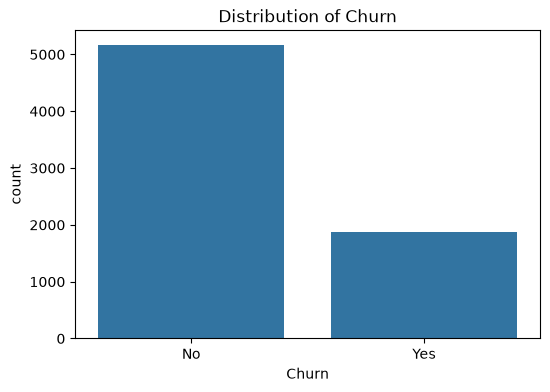

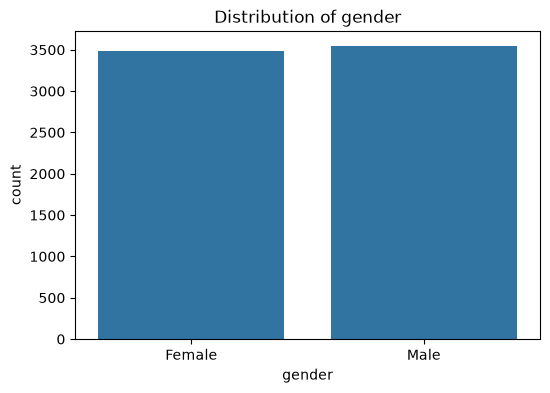

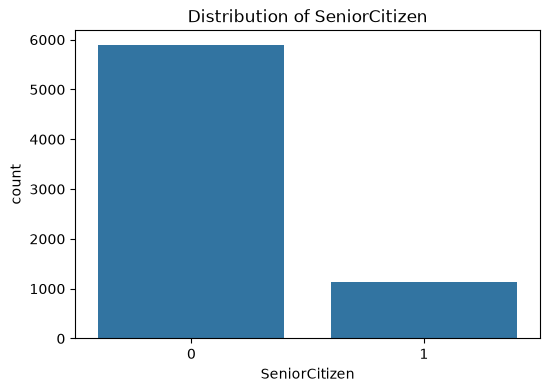

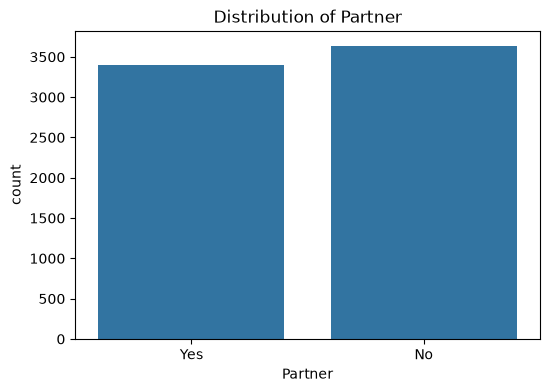

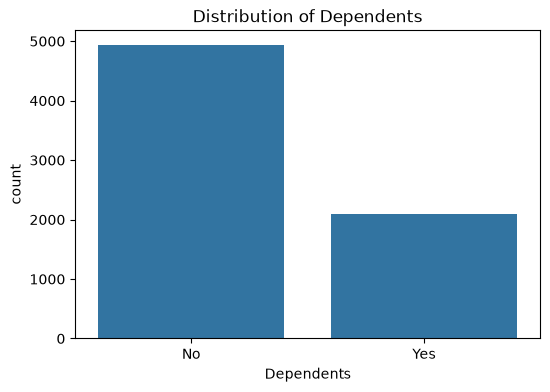

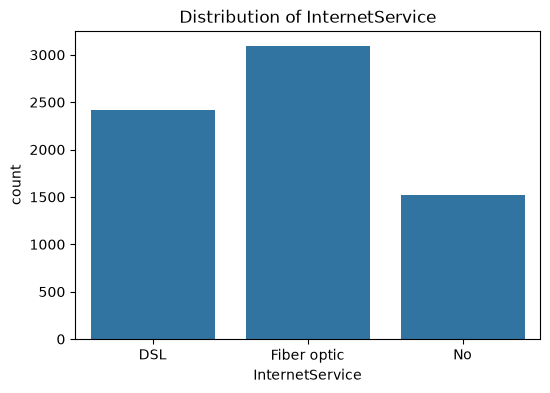

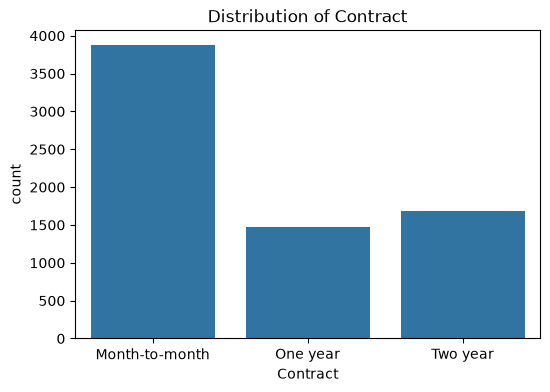

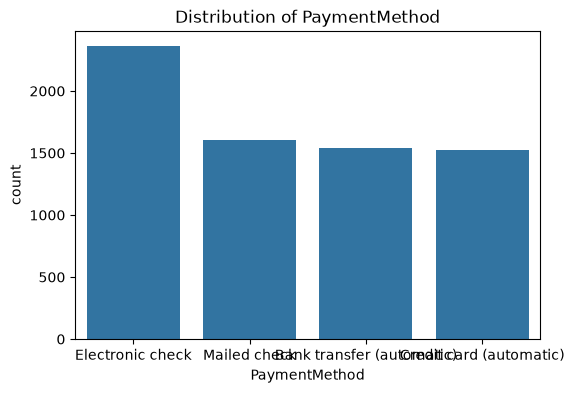

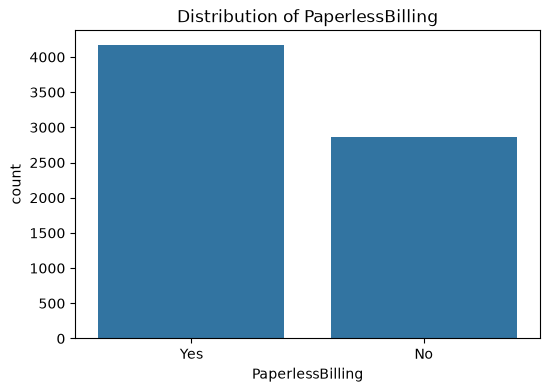

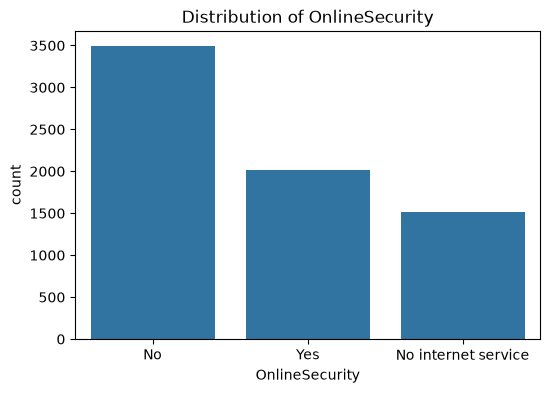

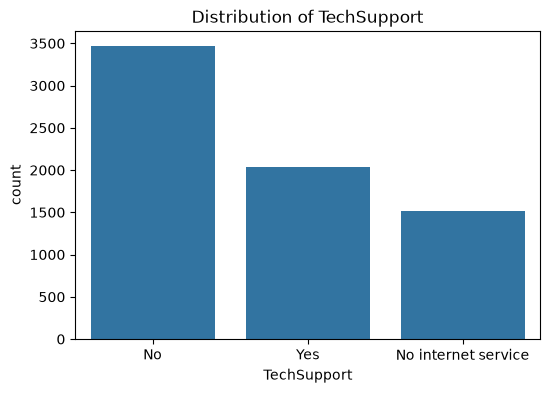

In [12]:
#Univariate Analysis
categorical_columns = [
    'Churn', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
    'InternetService', 'Contract', 'PaymentMethod',
    'PaperlessBilling', 'OnlineSecurity', 'TechSupport'
]

for col in categorical_columns:
    plt.figure(figsize=(6,4))
    sns.countplot(x = col, data= df)
    plt.title(f"Distribution of {col}")
    plt.show()

###  Distribution of Churn
### Inference:
- Most customers are retained, while a smaller proportion have churned.
- The dataset is moderately imbalanced, with approximately 73% retained and 27% churned customers.
- This indicates that although most customers stay with the company, customer churn remains a significant business concern.

### Distribution of Gender
### Inference:
- Male and female customers are almost equally distributed.
- The dataset is balanced with respect to gender.
- There is no major gender imbalance in the customer population.

### Distribution of Senior Citizen
### Inference:
- The majority of customers are non-senior citizens.
- Senior citizens represent only a small proportion of the customer base.
- The dataset is dominated by younger or middle-aged customers.

### Distribution of Partner
### Inference:
- Customers with and without partners are almost equally represented in the dataset.
- There is no significant imbalance between the two groups.
- Partner status alone may not strongly influence customer distribution.

### Distribution of Dependents
### Inference:
- A majority of customers do not have dependents.
- Customers with dependents represent a smaller portion of the customer base.
- The dataset is dominated by customers without dependents

###  Distribution of Internet Service
### Inference:
- Fiber Optic is the most commonly used internet service.
- DSL is the second most popular service.
- A smaller number of customers do not use internet services.
- Internet service type is likely to be an important feature in churn prediction.

### Distribution of Contract
### Inference:
- Most customers have Month-to-Month contracts.
- One-Year and Two-Year contracts have significantly fewer customers.
- This indicates that most customers prefer flexible subscription plans.

### Distribution of Payment Method
### Inference:
- Electronic Check is the most frequently used payment method.
- Mailed Check, Bank Transfer (Automatic), and Credit Card (Automatic) are used by comparatively fewer customers.
- Customer preference is skewed toward electronic payment methods.

### Distribution of Paperless Billing
### Inference:
- Most customers have Paperless Billing enabled.
- A smaller proportion of customers still use traditional paper billing.
- This indicates that digital billing is the preferred option among customers.

### Distribution of Online Security
### Inference:
- Most customers do not have Online Security.
- Fewer customers have subscribed to the Online Security service.
- A considerable number of customers do not have internet service, so Online Security is not applicable to them.
- This suggests that Online Security is not widely adopted among internet users.

### Distribution of Tech Support
### Inference:
- Most customers do not subscribe to Tech Support.
- A smaller proportion of customers have Tech Support enabled.
- Some customers do not have internet service, making Tech Support unavailable to them.
- Tech Support adoption is relatively low.


### Numerical Variables
- Histogram
- Box Plot

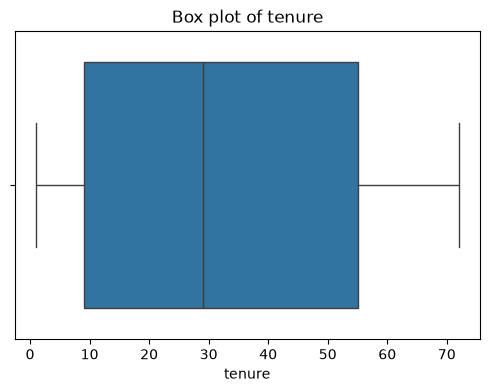

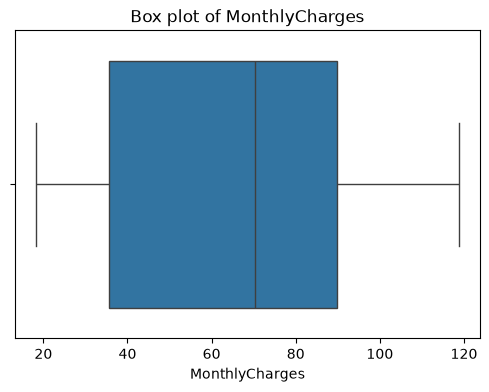

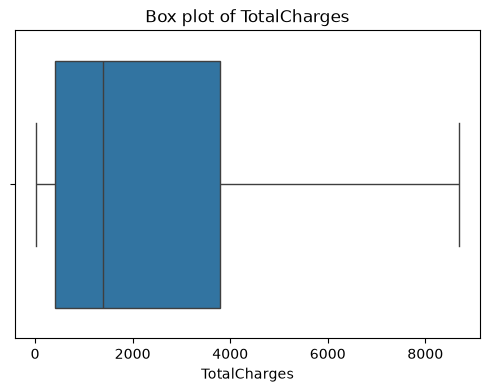

In [13]:
numeric_col = ["tenure", "MonthlyCharges", "TotalCharges"]

for col in numeric_col:
    plt.figure(figsize=(6,4))
    sns.boxplot(x = df[col])
    plt.title(f"Box plot of {col}")
    plt.show()

### Box Plot of Tenure
### Inference:
- Customer tenure ranges from 0 to 72 months.
- The median tenure is approximately 29 months.
- There are no significant outliers.
- The dataset contains both new and long-term customers, indicating a diverse customer base.

### Box Plot of Monthly Charges
### Inference:
- Monthly charges range approximately from ₹18 to ₹119.
- The median monthly charge is around ₹70.
- No significant outliers are observed, indicating that most customers pay within a reasonable range.
- Customers are subscribed to a variety of plans with different pricing.

### Box Plot of Total Charges
### Inference:
- Total charges vary from approximately ₹19 to ₹8,685.
- The distribution is positively skewed because customers with longer tenure accumulate higher total charges.
- No major outliers are observed.
- Higher total charges are mainly associated with long-term customers.

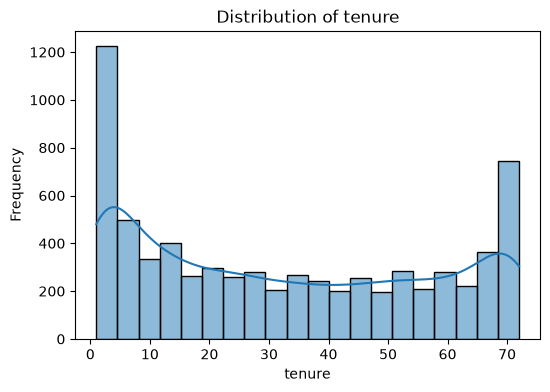

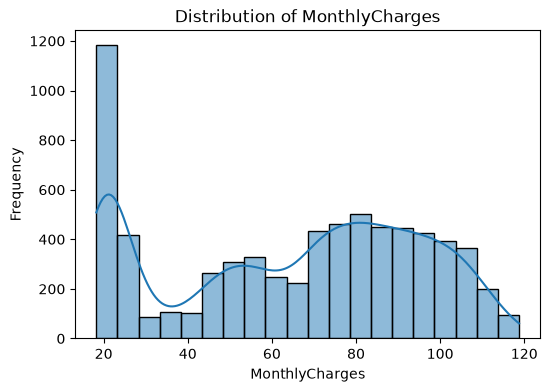

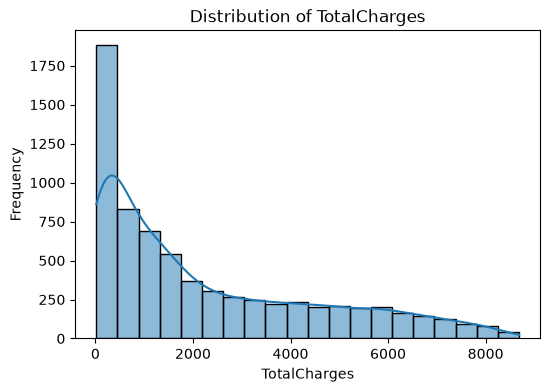

In [14]:
#Histograms -
numerical_columns = ['tenure', 'MonthlyCharges', 'TotalCharges']

for col in numerical_columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], bins=20, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

### Histogram of Tenure

- There is a high concentration of customers with very low tenure (new customers) and very high tenure (long-term customers).
- Fewer customers fall in the middle tenure range.
- This suggests the company has both newly acquired customers and a loyal long-term customer base.

### Histogram of Monthly Charges

- Monthly charges range from approximately ₹18 to ₹119.
- Most customers pay between ₹60 and ₹100 per month.
- The distribution is not perfectly normal, indicating customers subscribe to different service plans with varying prices.

### Histogram of Total Charges

- The distribution is positively (right) skewed.
- Most customers have relatively low total charges.
- A smaller number of long-term customers have accumulated very high total charges over time.

## Bivariate Analysis

Analyze the relationship between each important feature and the target variable (*Churn*)

### Categorical Variables vs Churn
- Count Plot with Hue

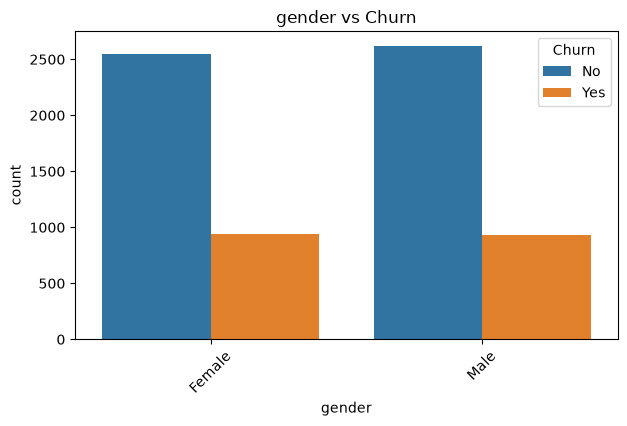

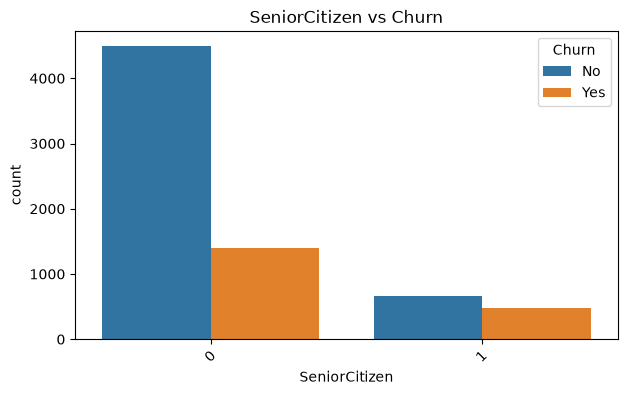

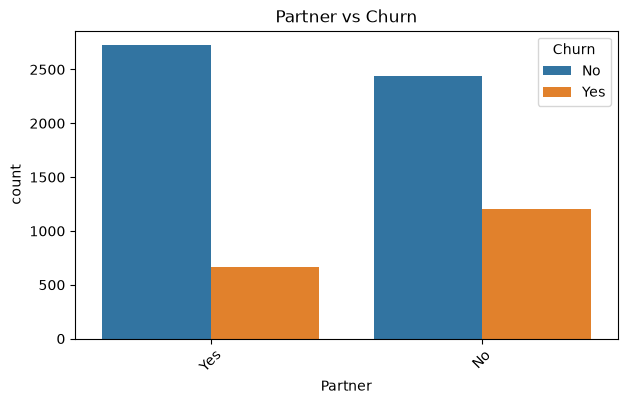

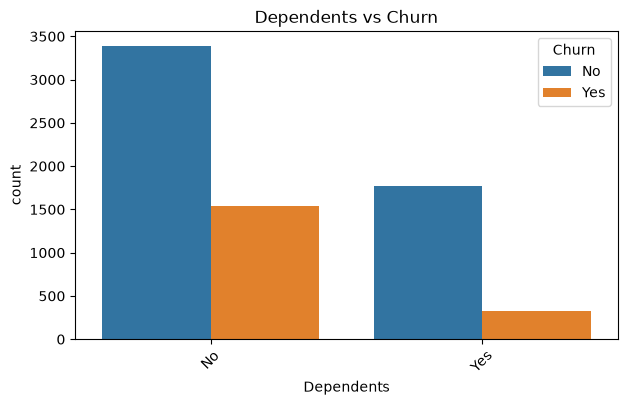

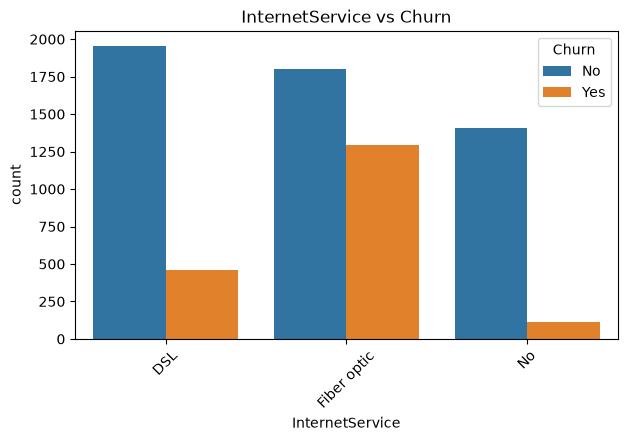

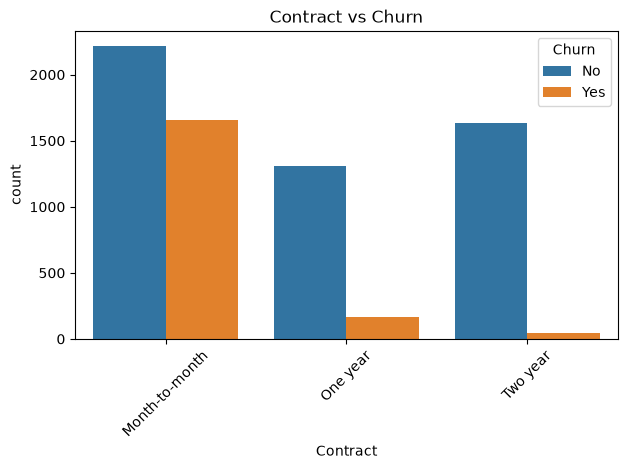

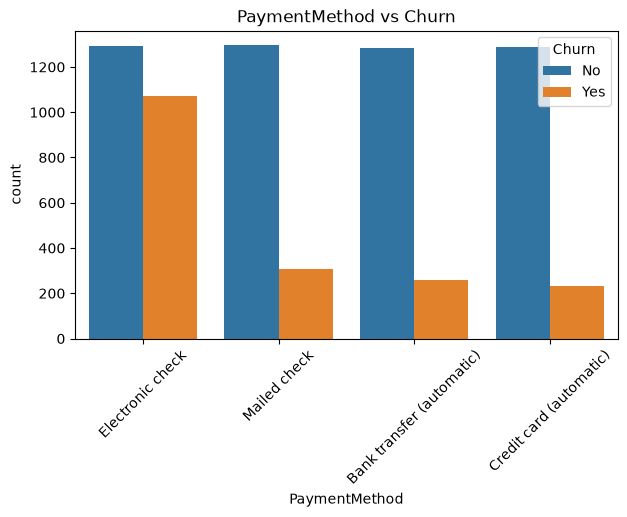

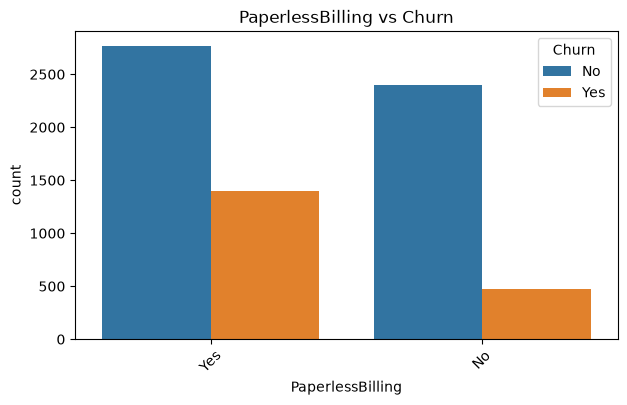

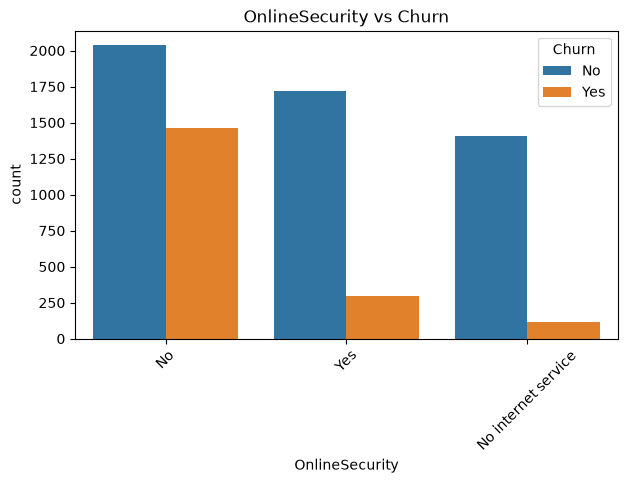

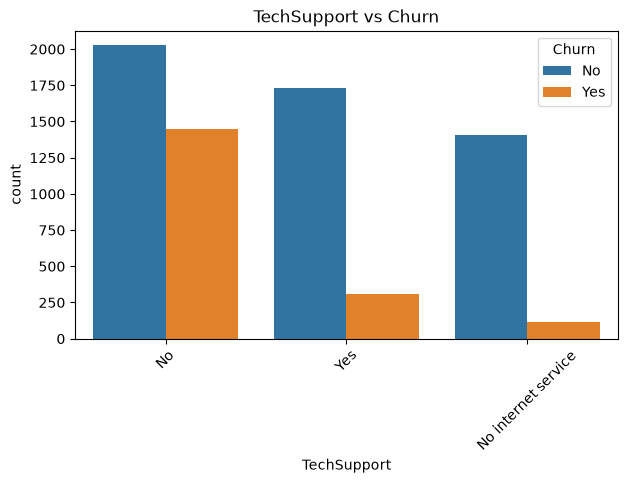

In [15]:
categorical_columns = [
    'gender',
    'SeniorCitizen',
    'Partner',
    'Dependents',
    'InternetService',
    'Contract',
    'PaymentMethod',
    'PaperlessBilling',
    'OnlineSecurity',
    'TechSupport'
]

for col in categorical_columns:
    plt.figure(figsize=(7,4))
    sns.countplot(x=col, hue='Churn', data=df)
    plt.title(f'{col} vs Churn')
    plt.xticks(rotation=45)
    plt.show()

### Gender vs Churn

- Male and female customers exhibit very similar churn patterns.
- The churn rate is nearly equal across both genders.
- Gender does not appear to be a strong predictor of customer churn

### Senior Citizen vs Churn

- Senior citizens have a higher proportion of churn compared to non-senior customers.
- Although senior citizens are fewer in number, they leave the company more frequently.
- Senior citizens may require targeted retention strategies.

### 27. Partner vs Churn

- Customers without a partner churn more frequently than customers with a partner.
- Customers with a partner show better retention.
- Partner status appears to have a positive effect on customer loyalty.

### Dependents vs Churn

- Customers without dependents have a noticeably higher number of churn cases.
- Customers with dependents are more likely to remain with the company.
- Having dependents appears to increase customer loyalty and reduce churn.
- Dependents can be considered an important feature for churn prediction

### Internet Service vs Churn

- Fiber Optic customers show the highest number of churn cases.
- DSL customers experience comparatively lower churn.
- Customers without internet service have the lowest churn.
- Internet service type is an important factor influencing customer churn.

### Contract vs Churn

- Customers with Month-to-Month contracts have the highest churn.
- Customers with One-Year and especially Two-Year contracts have much lower churn.
- Longer contract commitments are associated with better customer retention.
- Contract type is one of the strongest factors influencing churn. 

### Payment Method vs Churn

- Customers paying through Electronic Check have the highest churn.
- Customers using Automatic Bank Transfer or Automatic Credit Card have much lower churn.
- Automatic payment methods appear to improve customer retention.

### Paperless Billing vs Churn

- Customers using Paperless Billing have a higher number of churn cases.
- Customers who do not use Paperless Billing are less likely to churn.
- Paperless Billing is associated with higher churn, although it may also be related to other factors such as contract type.

### Online Security vs Churn

- Customers without Online Security have the highest churn.
- Customers who have Online Security are much more likely to stay with the company.
- Customers without internet service have very low churn.
- Providing Online Security may improve customer retention.

### Tech Support vs Churn

- Customers without Tech Support have the highest churn.
- Customers who subscribe to Tech Support are much more likely to stay with the company.
- Customers without internet service show very low churn.
- Providing Tech Support can improve customer satisfaction and reduce churn.

### Numerical Variables vs Churn
- Box Plot

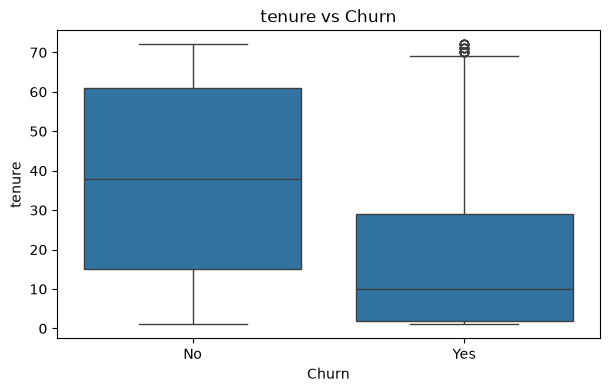

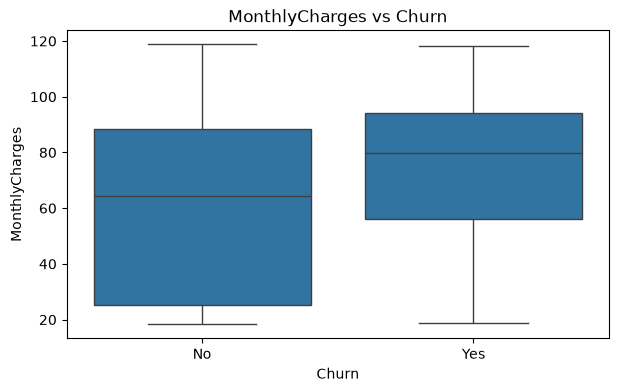

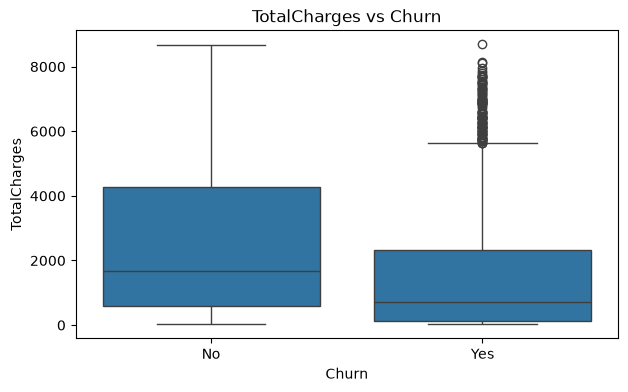

In [16]:
numeric_col = ["tenure", "MonthlyCharges", "TotalCharges"]

for col in numeric_col:
    plt.figure(figsize=(7,4))
    sns.boxplot(x = "Churn", y = col, data = df)
    plt.title(f'{col} vs Churn')
    plt.show()

### Tenure vs Churn

- Customers who churn generally have lower tenure than customers who stay.
- Long-term customers are much less likely to churn.
- Customer loyalty increases as tenure increases.
- Tenure is one of the strongest predictors of customer churn

### Monthly Charges vs Churn

- Customers who churn generally have higher monthly charges than customers who stay.
- Higher monthly charges appear to increase the likelihood of customer churn.

### Total Charges vs Churn

- Customers who churn generally have lower total charges than retained customers.
- Customers with higher total charges are typically long-term customers and are less likely to churn.
- Since total charges accumulate over time, this finding supports the observation that customers with longer tenure are more loyal.
- Total Charges is an important feature for predicting customer churn

## Multivariate Analysis

Analyze the combined effect of multiple variables on customer churn.

Examples include:

- Contract + InternetService + Churn
- SeniorCitizen + Contract + Churn
- MonthlyCharges + Contract + Churn
- Tenure + Contract + Churn
- Correlation Heatmap (after encoding)

<Figure size 800x500 with 0 Axes>

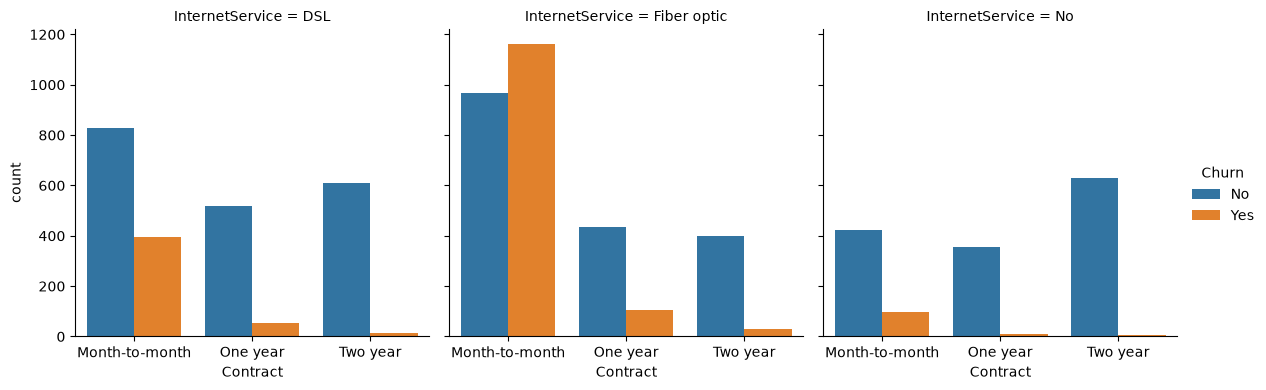

In [17]:
plt.figure(figsize=(8,5))
sns.catplot(
    x='Contract',
    hue='Churn',
    col='InternetService',
    data=df,
    kind='count',
    height=4,
    aspect=1
)

plt.show()

### Contract + Internet Service vs Churn

- Customers using Fiber Optic internet on Month-to-Month contracts show the highest churn.
- Customers with longer contracts generally have lower churn regardless of internet service.
- Combining contract type and internet service provides a better understanding of churn behavior.
- Customers with Month-to-Month contracts may require targeted retention strategies.

<Figure size 800x500 with 0 Axes>

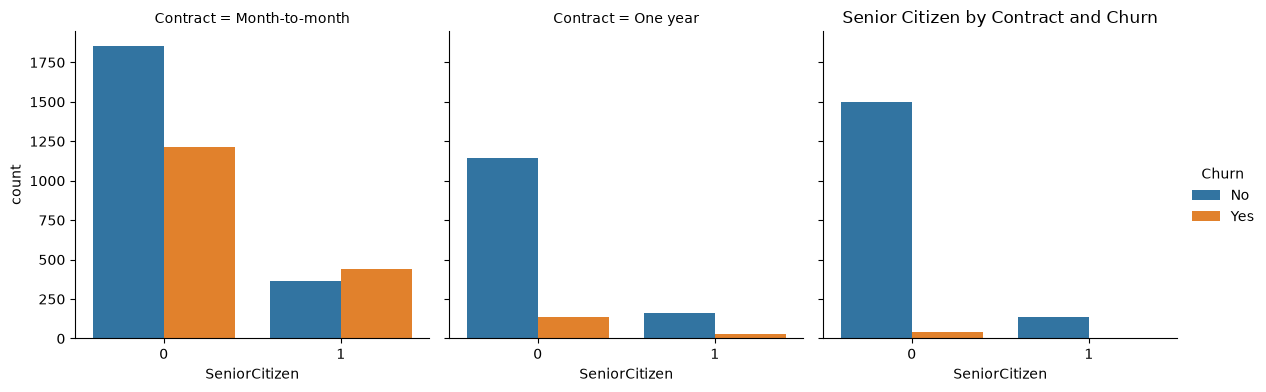

In [18]:
plt.figure(figsize=(8,5))
sns.catplot(
    x='SeniorCitizen',
    hue='Churn',
    col='Contract',
    data=df,
    kind='count',
    height=4,
    aspect=1
)
plt.title('Senior Citizen by Contract and Churn')
plt.show()

### Senior Citizen + Contract vs Churn

- Senior citizens with Month-to-Month contracts show the highest churn.
- Churn decreases substantially for both senior and non-senior customers on One-Year and Two-Year contracts.
- Long-term contracts reduce churn across all age groups.
- Converting senior customers from Month-to-Month to long-term contracts could significantly improve retention.

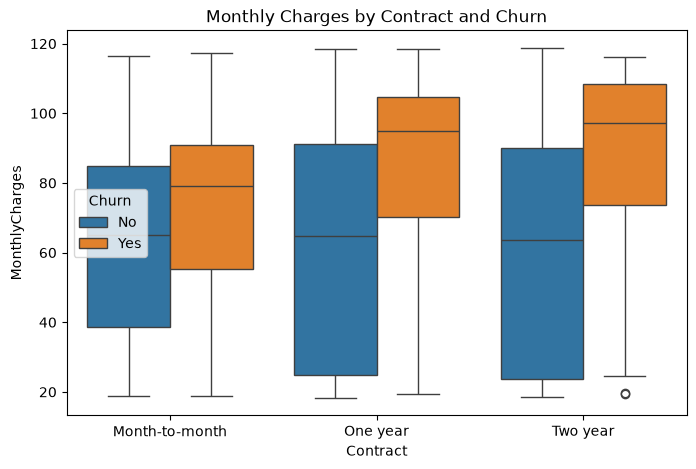

In [19]:
plt.figure(figsize=(8,5))
sns.boxplot(
    x='Contract',
    y='MonthlyCharges',
    hue='Churn',
    data=df
)
plt.title('Monthly Charges by Contract and Churn')
plt.show()

### Monthly Charges + Contract vs Churn

- Customers with Month-to-Month contracts and higher monthly charges have the highest churn.
- Customers with One-Year and Two-Year contracts are more likely to stay even if they pay higher monthly charges.
- Long-term contracts reduce churn and improve customer retention.
- This suggests that encouraging customers to move from Month-to-Month to longer-term contracts could help lower churn

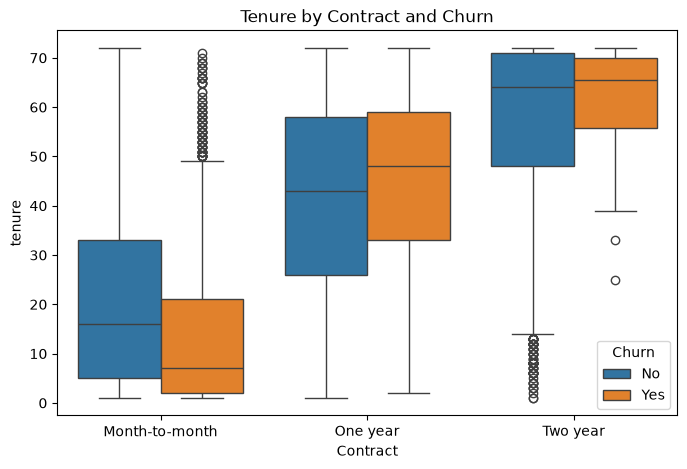

In [20]:
plt.figure(figsize=(8,5))
sns.boxplot(
    x='Contract',
    y='tenure',
    hue='Churn',
    data=df
)
plt.title('Tenure by Contract and Churn')
plt.show()

### Tenure + Contract vs Churn

- Customers with Month-to-Month contracts tend to churn early, with lower tenure.
- Customers on One-Year and Two-Year contracts have significantly longer tenure and lower churn.
- Longer contracts encourage customers to stay with the company for a longer period.
- Contract type and tenure together are strong indicators of customer retention.

# Data Preprocessing for Machine Learning
## 1. Removed Unnecessary Columns

Dropped the customerID column since it is a unique identifier and does not contribute to predicting customer churn.

In [32]:
df.drop('customerID', axis =1, inplace  = True)
print(df.columns)

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges',
       'Churn', 'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_Fiber optic', 'InternetService_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No internet service', 'OnlineBackup_Yes',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='str')


## 2. Identified Binary and Multi-Class Categorical Features

Examined categorical columns to identify binary features (Yes/No, Male/Female) and multi-class features for appropriate encoding

In [33]:
for col in df.select_dtypes(include = 'object').columns:
    print(col, ":", df[col].nunique())

## 3. Applied Label Encoding

Applied Label Encoding to binary categorical columns by converting two categories into numerical values (0 and 1).

In [34]:
binary_col = ["gender", "Partner", "Dependents", "PhoneService","PaperlessBilling","Churn"]
le = LabelEncoder()

for col in binary_col:
    df[col] = le.fit_transform(df[col])
    

## 4. Applied One-Hot Encoding

Applied One-Hot Encoding to categorical columns having more than two categories. Used drop_first=True to avoid multicollinearity and reduce redundant features

In [35]:
multi_cols = [
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'Contract',
    'PaymentMethod'
]

df = pd.get_dummies(df, columns=multi_cols, drop_first=True)

print(df.shape)
print(df.dtypes)
print(df.head())

KeyError: "None of [Index(['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',\n       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',\n       'Contract', 'PaymentMethod'],\n      dtype='str')] are in the [columns]"

## 5. Separated Features and Target Variable

Separated the independent variables (X) from the target variable (y) for model training.

In [25]:
X = df.drop('Churn', axis = 1)

y = df['Churn']
print(X.shape)
print(y.shape)
print(X.head())
print(y.head())

(7032, 31)
(7032,)
   customerID  gender  SeniorCitizen  Partner  Dependents  tenure  \
0  7590-VHVEG       0              0        1           0       1   
1  5575-GNVDE       1              0        0           0      34   
2  3668-QPYBK       1              0        0           0       2   
3  7795-CFOCW       1              0        0           0      45   
4  9237-HQITU       0              0        0           0       2   

   PhoneService  PaperlessBilling  MonthlyCharges  TotalCharges  ...  \
0             0                 1           29.85         29.85  ...   
1             1                 0           56.95       1889.50  ...   
2             1                 1           53.85        108.15  ...   
3             0                 0           42.30       1840.75  ...   
4             1                 1           70.70        151.65  ...   

   TechSupport_Yes  StreamingTV_No internet service  StreamingTV_Yes  \
0            False                            False          

## 6. Performed Train-Test Split

Split the dataset into training and testing sets using an 80:20 ratio. Used stratify=y to maintain the same churn class distribution in both sets.

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 42, stratify=y)
print(X_train.shape, X_test.shape, y_train, y_test)


(5625, 31) (1407, 31) 1413    0
7003    0
3355    0
4494    0
3541    0
       ..
3451    0
5123    1
4135    0
4249    0
1505    1
Name: Churn, Length: 5625, dtype: int64 974     0
619     0
4289    0
3721    1
4533    0
       ..
4829    0
5176    0
2750    0
4432    0
2091    0
Name: Churn, Length: 1407, dtype: int64


## 7. Applied Feature Scaling

Standardized the numerical features (tenure, MonthlyCharges, and TotalCharges) using StandardScaler to ensure all numerical variables are on the same scale before training the machine learning model.

In [27]:
scaler = StandardScaler()

numerical_columns = ['tenure', 'MonthlyCharges', 'TotalCharges']

X_train[numerical_columns] = scaler.fit_transform(X_train[numerical_columns])

X_test[numerical_columns] = scaler.transform(X_test[numerical_columns])

print(X_train[numerical_columns].head())
print(X_test[numerical_columns].head())

        tenure  MonthlyCharges  TotalCharges
1413  1.321816        0.981556      1.659900
7003 -0.267410       -0.971546     -0.562252
3355  1.444064        0.837066      1.756104
4494 -1.204646        0.641092     -0.908326
3541  0.669826       -0.808787     -0.101561
        tenure  MonthlyCharges  TotalCharges
974   1.077320        0.363738      0.984674
619  -1.041649        0.450100     -0.781798
4289  0.873573       -1.491376     -0.537223
3721 -1.245396       -1.473107     -0.994619
4533  1.566313        1.333645      2.308692


## 8. Verified the Processed Dataset

Verified the transformed training and testing datasets to ensure preprocessing steps were successfully applied.

In [28]:
print(X_train.head())
print(X_test.head())

      customerID  gender  SeniorCitizen  Partner  Dependents    tenure  \
1413  1830-GGFNM       1              0        1           1  1.321816   
7003  4501-VCPFK       1              0        0           0 -0.267410   
3355  8871-JLMHM       0              0        1           0  1.444064   
4494  0225-ZORZP       1              0        0           0 -1.204646   
3541  1530-ZTDOZ       0              0        1           0  0.669826   

      PhoneService  PaperlessBilling  MonthlyCharges  TotalCharges  ...  \
1413             1                 0        0.981556      1.659900  ...   
7003             0                 0       -0.971546     -0.562252  ...   
3355             1                 0        0.837066      1.756104  ...   
4494             1                 0        0.641092     -0.908326  ...   
3541             0                 0       -0.808787     -0.101561  ...   

      TechSupport_Yes  StreamingTV_No internet service  StreamingTV_Yes  \
1413             True        

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score,roc_curve
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

#create and train the model
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

#make predictions
y_pred = log_reg.predict(X_test)
y_prob = log_reg.predict_proba(X_test)

#evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))

#Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

#Classification report
print(classification_report(y_test, y_pred))

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

#ROC curve
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_prob):.2f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

ValueError: could not convert string to float: '1830-GGFNM'

In [ ]:
print(X_train.columns)


Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'PaperlessBilling', 'MonthlyCharges',
       'TotalCharges', 'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_Fiber optic', 'InternetService_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No internet service', 'OnlineBackup_Yes',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='str')
